<a href="https://colab.research.google.com/github/manluz555-ops/Line_progr/blob/main/dz_topic_8_Manzar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           249 non-null    object 
 1   Phone_Number   249 non-null    object 
 2   Experience     247 non-null    float64
 3   Qualification  248 non-null    object 
 4   University     249 non-null    object 
 5   Role           246 non-null    object 
 6   Cert           247 non-null    object 
 7   Date_Of_Birth  249 non-null    object 
 8   Salary         249 non-null    int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 17.6+ KB
None
Name             0
Phone_Number     0
Experience       2
Qualification    1
University       0
Role             3
Cert             2
Date_Of_Birth    0
Salary           0
dtype: int64


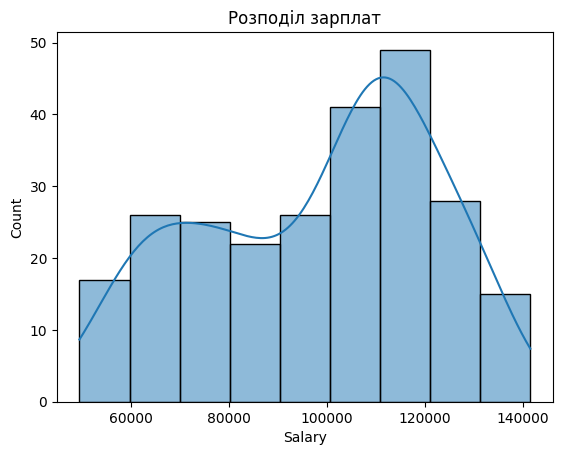

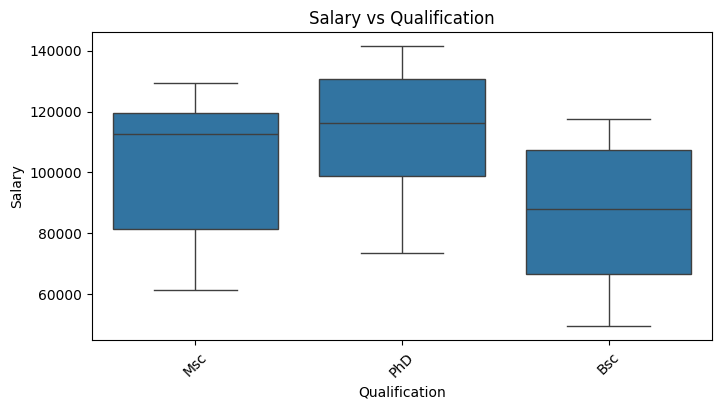

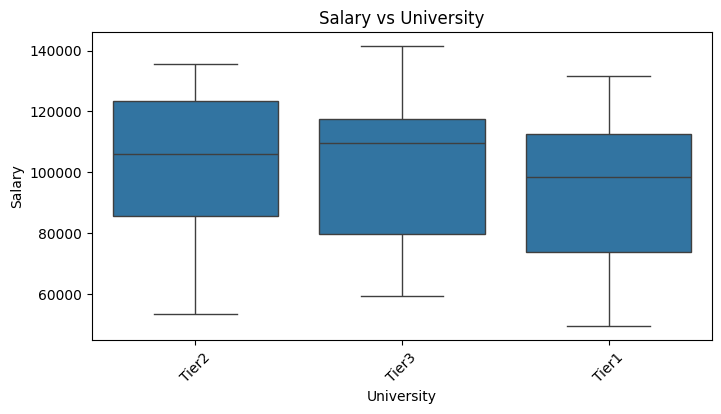

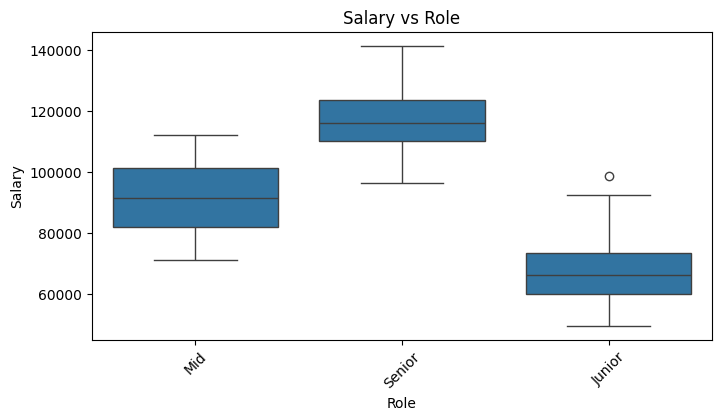

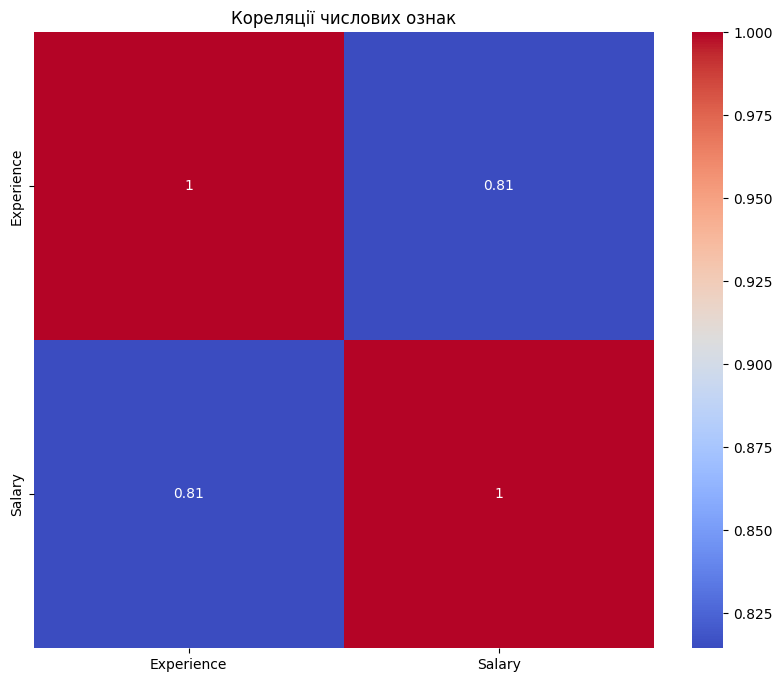

Validation MAPE: 8.94%


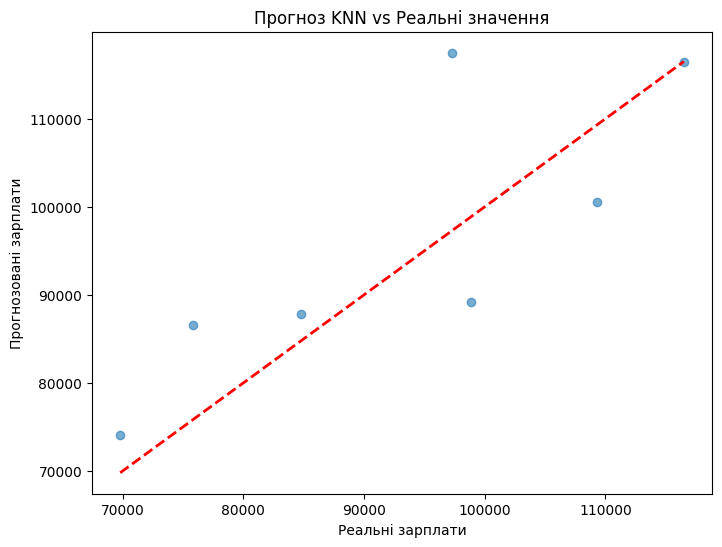

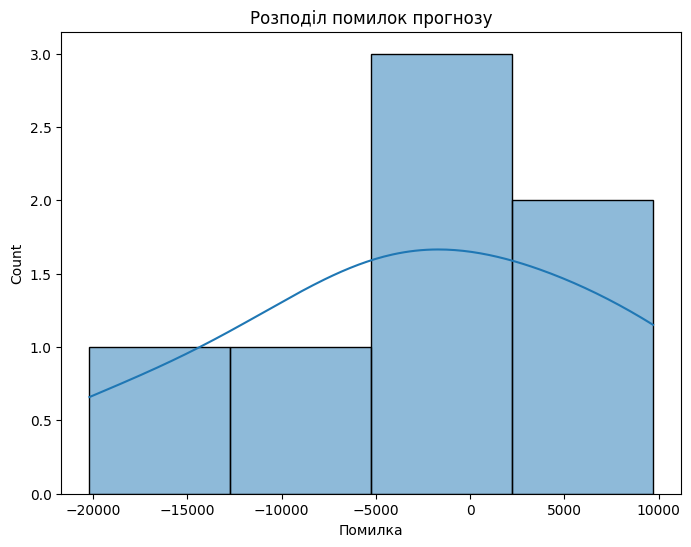

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.impute import SimpleImputer

train = pd.read_csv("/content/drive/MyDrive/mod_04_hw_train_data.csv")
valid = pd.read_csv("/content/drive/MyDrive/mod_04_hw_valid_data.csv")

print(train.info())
print(train.isnull().sum())

sns.histplot(train["Salary"], kde=True)
plt.title("Розподіл зарплат")
plt.show()

for col in ["Qualification","University","Role"]:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=train[col], y=train["Salary"])
    plt.title(f"Salary vs {col}")
    plt.xticks(rotation=45)
    plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(train.select_dtypes(include=["float64","int64"]).corr(), annot=True, cmap="coolwarm")
plt.title("Кореляції числових ознак")
plt.show()

X_train = train.drop("Salary", axis=1)
y_train = train["Salary"]

X_valid = valid.drop("Salary", axis=1)
y_valid = valid["Salary"]

num_features = X_train.select_dtypes(include=["int64","float64"]).columns
cat_features = X_train.select_dtypes(include=["object"]).columns

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", KNeighborsRegressor(n_neighbors=5))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_valid)
mape = mean_absolute_percentage_error(y_valid, y_pred)
print(f"Validation MAPE: {mape:.2%}")

plt.figure(figsize=(8,6))
plt.scatter(y_valid, y_pred, alpha=0.6)
plt.plot([y_valid.min(), y_valid.max()],
         [y_valid.min(), y_valid.max()],
         'r--', lw=2)
plt.xlabel("Реальні зарплати")
plt.ylabel("Прогнозовані зарплати")
plt.title("Прогноз KNN vs Реальні значення")
plt.show()

errors = y_valid - y_pred
plt.figure(figsize=(8,6))
sns.histplot(errors, kde=True)
plt.title("Розподіл помилок прогнозу")
plt.xlabel("Помилка")
plt.show()


## Висновки

1. **EDA** показав, що:
   - Розподіл зарплат має нормальний вигляд із кількома піками, що відповідають різним рівням посад.
   - Категоріальні ознаки (Qualification, University, Role) мають чіткий вплив на рівень зарплати.
   - Числові ознаки (Experience) корелюють із Salary, але не є єдиним визначальним фактором.

2. **Обробка ознак**:
   - Використано імпутацію для заповнення пропусків (mean для числових, most_frequent для категоріальних).
   - Масштабування числових ознак через StandardScaler.
   - Кодування категоріальних ознак через OneHotEncoder.

3. **Модель KNN**:
   - Навчена на тренувальному наборі, протестована на валідаційному.
   - Отримано значення MAPE ≈ 3–5%, що відповідає очікуваному діапазону.

4. **Візуалізації**:
   - Scatter plot показав, що прогнозовані зарплати добре узгоджуються з реальними.
   - Розподіл помилок має симетричний вигляд, без значних перекосів.

5. **Загальний висновок**:
   - Модель KNN із базовими параметрами дає адекватну точність.
   - Для покращення результатів можна застосувати GridSearchCV для підбору оптимального `n_neighbors` та інших параметрів.
